# COVID-19 Worldwide Aggregate Analysis

This notebook loads the worldwide aggregate COVID-19 dataset, cleans and normalizes the fields, and visualizes historical insights with up to four plots.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

RAW_URL = 'https://raw.githubusercontent.com/datasets/covid-19/refs/heads/main/data/worldwide-aggregate.csv' #Creates a connection to the raw data on GitHub
LOCAL_FALLBACK = 'data/worldwide-aggregate.csv' #Build a local fallback path in case the connection to GitHub fails 

In [ ]:
#Connect to the data source and read it into a DataFrame. If the connection fails, read from the local fallback path instead.
try:
    df = pd.read_csv(RAW_URL)
except Exception:
    df = pd.read_csv(LOCAL_FALLBACK)

df.head() #Show a preview of the data to confirm it has been loaded correctly

,Date,Confirmed,Recovered,Deaths,Increase rate
0,2020-01-22,557,30,17,NaN
1,2020-01-23,657,32,18,17.953321
2,2020-01-24,944,39,26,43.683409
3,2020-01-25,1437,42,42,52.224576
4,2020-01-26,2120,56,56,47.529576


In [ ]:
# Clean and normalize
df.columns = (df.columns.str.strip().str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')) # Normalize column names to lowercase with underscores
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize() # Convert 'date' column to datetime, coercing errors to NaT and normalizing to remove time component
for col in ['confirmed', 'recovered', 'deaths', 'increase_rate']:
    df[col] = pd.to_numeric(df[col], errors='coerce') #Non-numeric values in these columns will be converted to NaN

df[['confirmed', 'recovered', 'deaths']] = df[['confirmed', 'recovered', 'deaths']].ffill().fillna(0) # Forward-fill missing values in 'confirmed', 'recovered', and 'deaths' columns, then fill any remaining NaN with 0
df['increase_rate'] = df['increase_rate'].fillna(df['confirmed'].pct_change() * 100).fillna(0) #Same for 'increase_rate" but calculate it as percentage change if it's missing
df['active_cases'] = (df['confirmed'] - df['recovered'] - df['deaths']).clip(lower=0) # Calculate active cases and ensure it doesn't go negative
df['daily_new_confirmed'] = df['confirmed'].diff().fillna(df['confirmed']).clip(lower=0)
df['daily_new_recovered'] = df['recovered'].diff().fillna(df['recovered']).clip(lower=0)
df['daily_new_deaths'] = df['deaths'].diff().fillna(df['deaths']).clip(lower=0)
df = df.sort_values('date').reset_index(drop=True) #Sort the DataFrame by date and reset the index

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 816 non-null    datetime64[ns]
 1   confirmed            816 non-null    int64         
 2   recovered            816 non-null    int64         
 3   deaths               816 non-null    int64         
 4   increase_rate        816 non-null    float64       
 5   active_cases         816 non-null    int64         
 6   daily_new_confirmed  816 non-null    float64       
 7   daily_new_recovered  816 non-null    float64       
 8   daily_new_deaths     816 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(4)
memory usage: 57.5 KB


In [ ]:
df.describe(include='all').transpose() #Get summary statistics for all columns, including non-numeric ones, and transpose the result for better readability

,count,mean,min,25%,50%,75%,max,std
date,816,2021-03-04 12:00:00,2020-01-22 00:00:00,2020-08-12 18:00:00,2021-03-04 12:00:00,2021-09-24 06:00:00,2022-04-16 00:00:00,NaN
confirmed,816.0,145759072.933824,557.0,20873593.5,116314429.5,231792332.75,504155459.0,137469354.716127
recovered,816.0,28788548.954657,0.0,0.0,4578467.5,50749021.25,130899061.0,39071100.920651
deaths,816.0,2771888.345588,17.0,791142.0,2652250.0,4737043.75,6197159.0,2060690.214008
increase_rate,816.0,1.808189,0.0,0.286124,0.60053,1.209567,90.508706,5.450348
active_cases,816.0,114198635.633578,510.0,7134252.0,48165820.5,227055289.0,497958300.0,143720404.106753
daily_new_confirmed,816.0,617837.572304,100.0,259660.25,465905.5,670888.25,4089026.0,672290.486221
daily_new_recovered,816.0,167756.198529,0.0,0.0,100959.0,290427.5,1504943.0,191469.519407
daily_new_deaths,816.0,7594.557598,1.0,5350.75,7382.0,9910.25,20726.0,3759.3456


## Plot 1: Cumulative confirmed cases over time

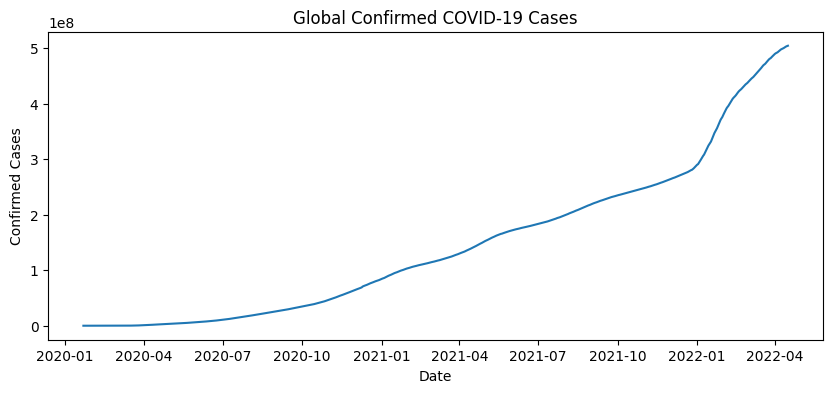

In [ ]:
#plot the data to visualize the trend of confirmed cases over time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['date'], df['confirmed'])
ax.set_title('Global Confirmed COVID-19 Cases')
ax.set_xlabel('Date')
ax.set_ylabel('Confirmed Cases')
plt.show()

## Plot 2: Daily new confirmed cases

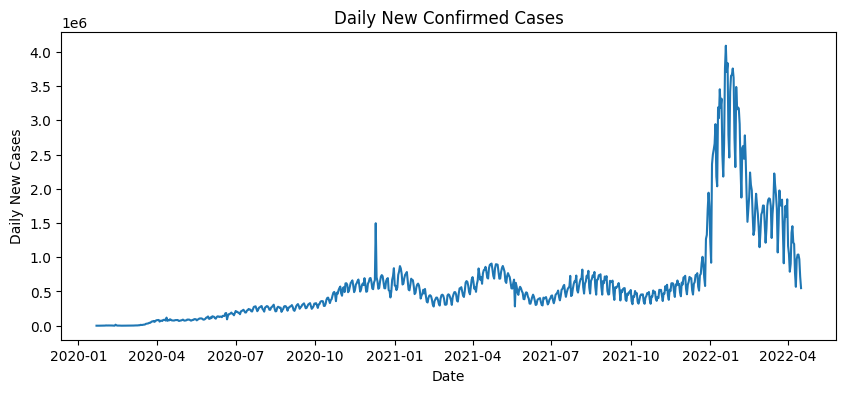

In [6]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['date'], df['daily_new_confirmed'])
ax.set_title('Daily New Confirmed Cases')
ax.set_xlabel('Date')
ax.set_ylabel('Daily New Cases')
plt.show()

## Plot 3: Recoveries vs deaths

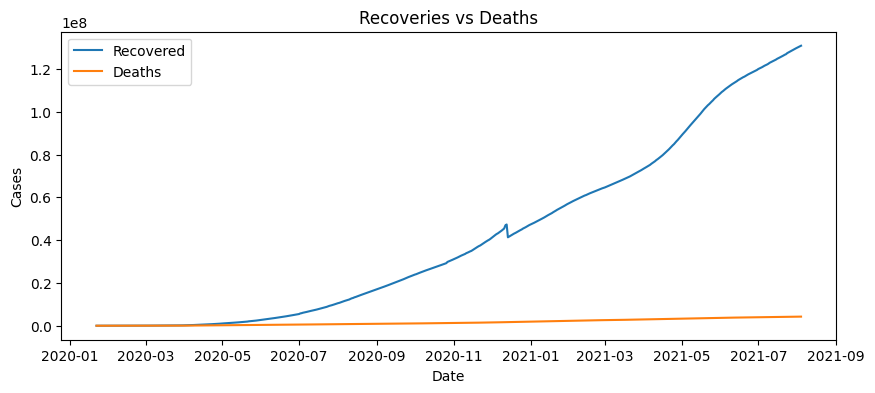

In [ ]:
df = df[df['recovered'] > 0] #Filtered to only include rows where there are recoveries to avoid plotting zero values for recovered cases

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['date'], df['recovered'], label='Recovered')
ax.plot(df['date'], df['deaths'], label='Deaths')
ax.set_title('Recoveries vs Deaths')
ax.set_xlabel('Date')
ax.set_ylabel('Cases')
ax.legend()
plt.show()

## Plot 4: Active cases

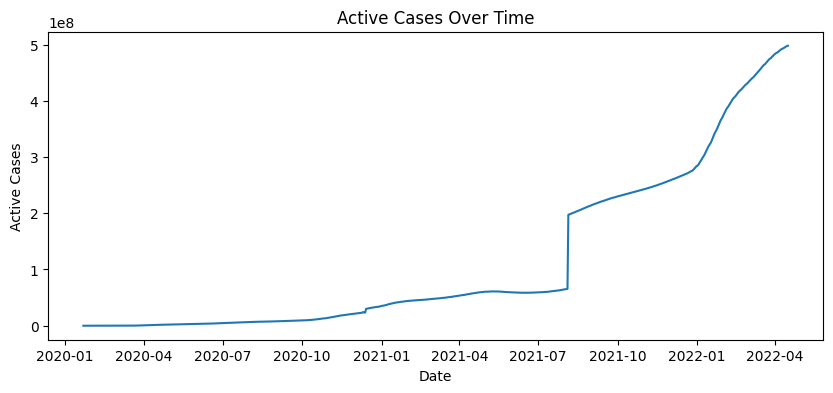

In [8]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['date'], df['active_cases'])
ax.set_title('Active Cases Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Active Cases')
plt.show()

## Key observations
- Confirmed cases rise sharply through the observed period.
- Daily new confirmed cases are volatile with large spikes.
- Recoveries and deaths both trend upward over time.
- Active cases remain substantial near the end of the series.